# Stochastic Volatility Proxy

A local volatility proxy captures latent volatility clustering without requiring a sampler.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bayesian_utils import ensure_output_dir, simulate_strategy_returns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()
from bayesian_utils import stochastic_volatility_proxy


In [2]:
returns = simulate_strategy_returns(periods=1_260, seed=505)['momentum']
vol = stochastic_volatility_proxy(returns, span=35)
vol.to_parquet(OUTPUT / 'stochastic_volatility_proxy.parquet')
vol.tail()

,return,realized_vol,latent_vol_proxy,shock_proxy
2026-05-04,0.0114,0.2609,0.2553,0.0143
2026-05-05,0.0283,0.2810,0.2697,0.0156
2026-05-06,-0.0052,0.2752,0.2628,0.0150
2026-05-07,0.0128,0.2718,0.2599,0.0149
2026-05-08,-0.0022,0.2574,0.2527,0.0139


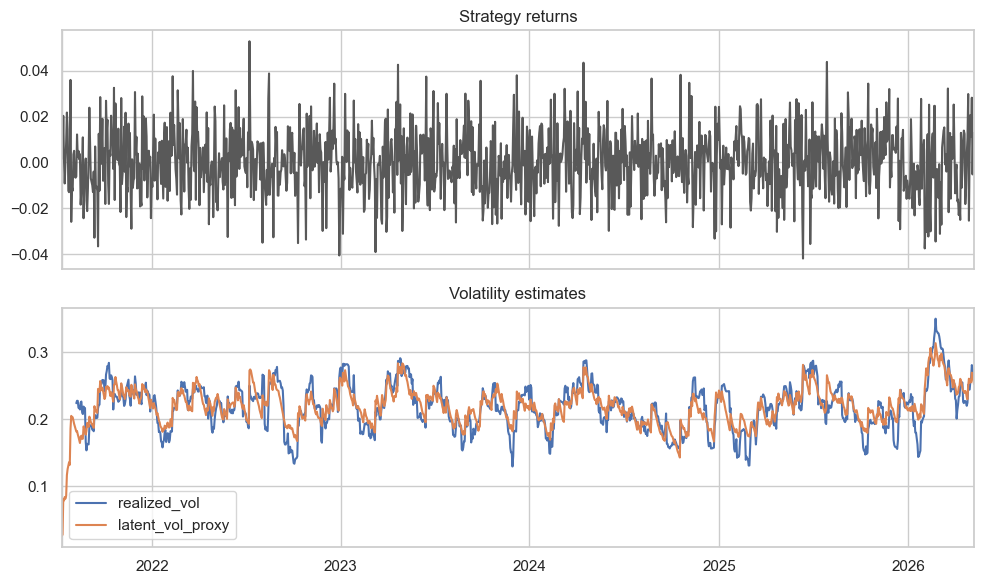

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
vol['return'].plot(ax=axes[0], color='0.35', title='Strategy returns')
vol[['realized_vol', 'latent_vol_proxy']].plot(ax=axes[1], title='Volatility estimates')
plt.tight_layout()